# LMArena Experiments: Estimators & Confidence Intervals

End-to-end benchmarks on the LMArena dataset (pairwise LLM preference judgments).

- **Part 1**: Point estimator benchmark (ALL_ESTIMATORS, MSE)
- **Part 2**: Confidence interval benchmark across multiple alpha levels
- **Part 3**: Plots of CI width and coverage vs. alpha

In [1]:
import sys, os, warnings
os.chdir(os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

# Suppress numpy RuntimeWarnings (e.g. from EB variance edge cases)
warnings.filterwarnings("ignore", category=RuntimeWarning, module="numpy")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from datasets.lmarena import LMArenaDataset
from estimators import ALL_ESTIMATORS
from intervals import CORE_CI_METHODS
from experiments import run_benchmark, run_ci_benchmark
from config import DEFAULT_KWARGS

In [2]:
dataset = LMArenaDataset(train_test_split=0.1)
print(f"LMArena: M={dataset.M} problems, "
      f"n_labeled=[{dataset.ns.min()}, {dataset.ns.max()}], "
      f"N_unlabeled=[{dataset.Ns.min()}, {dataset.Ns.max()}]")

LMArena: M=298 problems, n_labeled=[10, 27], N_unlabeled=[90, 249]


## Part 1: Point Estimator Benchmark (ALL_ESTIMATORS)

In [3]:
# Use share_var=False for all estimators that accept it
estimator_kwargs = {
    "pt": {"share_var": False, "get_lambdas": False},
    "shrinkage_only": {"get_lambdas": False, "share_var": False, "cutoff": 0.999},
    "pas": {"get_lambdas": False, "share_var": False, "cutoff": 0.999},
    "shrinkage_mean": {"cutoff": 0.999, "share_var": False, "get_lambdas": False},
    "uni_pas": {"get_lambda": False, "get_omega": False, "cutoff": 0.999},
    "uni_pt": {"get_lambda": False},
}

mse_results = run_benchmark(
    dataset, trials=200, summary=True,
    estimators=ALL_ESTIMATORS, estimator_kwargs=estimator_kwargs,
    verbose=False
)


Results for LMArena:

Mean of metrics:
mle                   0.01616588
pred_mean             0.01558301
ppi                   0.02939588
pt                    0.01656646
shrinkage_only        0.00827790
shrinkage_mean        0.00855121
pas                   0.00892154
uni_pt                0.01589060
uni_pas               0.00807400
eb_ppi                0.01086631
eb_unipt_ppi          0.00992576
mle_frac              0.00000000
pred_mean_frac        0.47489933
ppi_frac              0.38560403
pt_frac               0.29588926
shrinkage_only_frac   0.60255034
shrinkage_mean_frac   0.63087248
pas_frac              0.58890940
uni_pt_frac           0.52604027
uni_pas_frac          0.61557047
eb_ppi_frac           0.56310403
eb_unipt_ppi_frac     0.65203020
SD of metrics:
mle                   0.00132736
pred_mean             0.00017573
ppi                   0.00258200
pt                    0.00141297
shrinkage_only        0.00071079
shrinkage_mean        0.00067136
pas                  

In [4]:
# Show MSE columns only (drop _frac columns)
mse_cols = [c for c in mse_results.columns if not c.endswith("_frac")]
mse_results[mse_cols].describe().round(6)

,mle,pred_mean,ppi,pt,shrinkage_only,shrinkage_mean,pas,uni_pt,uni_pas,eb_ppi,eb_unipt_ppi
count,200.000000,200.00000,200.000000,200.000000,200.00000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000
unique,200.000000,200.00000,200.000000,200.000000,200.00000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000
top,0.016517,0.01544,0.031162,0.017115,0.00835,0.008914,0.008976,0.01612,0.007973,0.010495,0.010087
freq,1.000000,1.00000,1.000000,1.000000,1.00000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000


## Part 2: Confidence Interval Benchmark Across Alpha Levels

In [5]:
alphas = [0.01, 0.05, 0.10, 0.20, 0.30]
ci_kwargs = {"pt_ci": {"share_var": False}}
TRIALS = 200

# Store mean coverage and width per (alpha, method)
records = []

for alpha in alphas:
    print(f"Running CI benchmark with alpha={alpha} ... ", end="")
    ci_results = run_ci_benchmark(
        dataset, trials=TRIALS, alpha=alpha,
        summary=False, ci_kwargs=ci_kwargs,
        verbose=False
    )
    print("done")
    # Collect per-method summary
    for method in CORE_CI_METHODS:
        cov_col = f"{method}_coverage"
        wid_col = f"{method}_width"
        records.append({
            "alpha": alpha,
            "method": method,
            "mean_coverage": ci_results[cov_col].mean(),
            "se_coverage": ci_results[cov_col].sem(),
            "mean_width": ci_results[wid_col].mean(),
            "se_width": ci_results[wid_col].sem(),
        })

summary_df = pd.DataFrame(records)
summary_df

Running CI benchmark with alpha=0.01 ... done
Running CI benchmark with alpha=0.05 ... done
Running CI benchmark with alpha=0.1 ... done
Running CI benchmark with alpha=0.2 ... done
Running CI benchmark with alpha=0.3 ... done


,alpha,method,mean_coverage,se_coverage,mean_width,se_width
0,0.01,mle_ci,0.965185,0.000690,0.674770,0.000389
1,0.01,bootstrap_ci,0.971779,0.000651,0.603688,0.000427
2,0.01,ppi_ci,0.979010,0.000608,0.882329,0.000639
3,0.01,pt_ci,0.957701,0.000785,0.646643,0.000400
4,0.01,eb_ppi_ci,0.984681,0.000647,0.532030,0.002455
5,0.01,eb_unipt_ppi_ci,0.976711,0.000605,0.521266,0.000587
6,0.05,mle_ci,0.929262,0.000993,0.513436,0.000296
7,0.05,bootstrap_ci,0.929346,0.000984,0.475275,0.000313
8,0.05,ppi_ci,0.933775,0.001036,0.671370,0.000486
9,0.05,pt_ci,0.913406,0.001110,0.492034,0.000304


## Part 3: Plots — CI Width and Coverage vs. Alpha

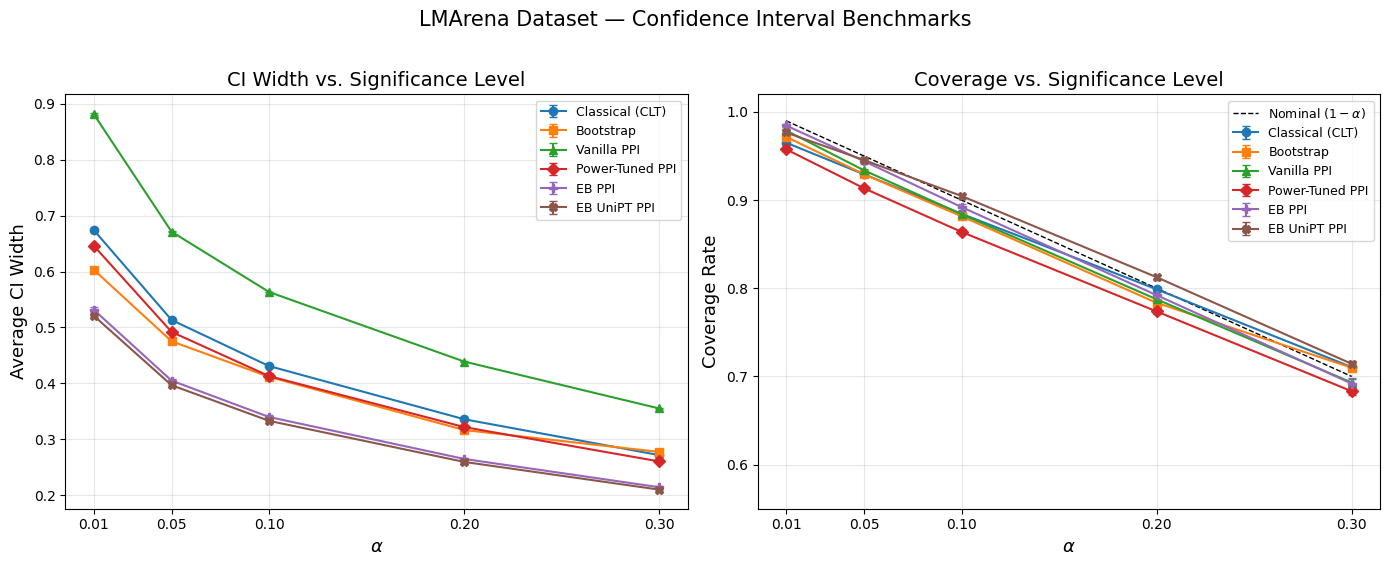

In [6]:
METHOD_LABELS = {
    "mle_ci": "Classical (CLT)",
    "bootstrap_ci": "Bootstrap",
    "ppi_ci": "Vanilla PPI",
    "pt_ci": "Power-Tuned PPI",
    "eb_ppi_ci": "EB PPI",
    "eb_unipt_ppi_ci": "EB UniPT PPI",
}
METHOD_COLORS = {
    "mle_ci": "#1f77b4",
    "bootstrap_ci": "#ff7f0e",
    "ppi_ci": "#2ca02c",
    "pt_ci": "#d62728",
    "eb_ppi_ci": "#9467bd",
    "eb_unipt_ppi_ci": "#8c564b",
}
METHOD_MARKERS = {
    "mle_ci": "o",
    "bootstrap_ci": "s",
    "ppi_ci": "^",
    "pt_ci": "D",
    "eb_ppi_ci": "P",
    "eb_unipt_ppi_ci": "X",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Left panel: CI Width vs Alpha ---
ax = axes[0]
for method in CORE_CI_METHODS:
    df_m = summary_df[summary_df["method"] == method]
    ax.errorbar(
        df_m["alpha"], df_m["mean_width"], yerr=1.96 * df_m["se_width"],
        label=METHOD_LABELS[method], color=METHOD_COLORS[method],
        marker=METHOD_MARKERS[method], capsize=3, linewidth=1.5,
    )
ax.set_xlabel(r"$\alpha$", fontsize=13)
ax.set_ylabel("Average CI Width", fontsize=13)
ax.set_title("CI Width vs. Significance Level", fontsize=14)
ax.legend(fontsize=9)
ax.set_xticks(alphas)
ax.grid(True, alpha=0.3)

# --- Right panel: Coverage vs Alpha ---
ax = axes[1]
for method in CORE_CI_METHODS:
    df_m = summary_df[summary_df["method"] == method]
    ax.errorbar(
        df_m["alpha"], df_m["mean_coverage"], yerr=1.96 * df_m["se_coverage"],
        label=METHOD_LABELS[method], color=METHOD_COLORS[method],
        marker=METHOD_MARKERS[method], capsize=3, linewidth=1.5,
    )
# Nominal coverage reference line
ax.plot(alphas, [1 - a for a in alphas], "k--", linewidth=1, label="Nominal $(1-\\alpha)$")
ax.set_xlabel(r"$\alpha$", fontsize=13)
ax.set_ylabel("Coverage Rate", fontsize=13)
ax.set_title("Coverage vs. Significance Level", fontsize=14)
ax.legend(fontsize=9)
ax.set_xticks(alphas)
ax.set_ylim(0.55, 1.02)
ax.grid(True, alpha=0.3)

fig.suptitle("LMArena Dataset — Confidence Interval Benchmarks", fontsize=15, y=1.02)
fig.tight_layout()
# cwd is src/ after os.chdir in setup cell
plt.savefig("scripts/lmarena_ci_benchmarks.pdf", bbox_inches="tight", dpi=150)
plt.show()